In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#project root
ROOT=Path.cwd().parent
#data directories
RAW_DATA=ROOT/"data"/"raw"
PROCESSED_DATA=ROOT/"data"/"processed"
print("Project root: ",ROOT)
print("Raw data: ",RAW_DATA)
print("Processed data: ",PROCESSED_DATA)

Project root:  D:\PIYUSH KUMAR MISHRA\JOB_PREPARATION\DataScience\MachineLearningProjects\ai-supply-chain-intelligence
Raw data:  D:\PIYUSH KUMAR MISHRA\JOB_PREPARATION\DataScience\MachineLearningProjects\ai-supply-chain-intelligence\data\raw
Processed data:  D:\PIYUSH KUMAR MISHRA\JOB_PREPARATION\DataScience\MachineLearningProjects\ai-supply-chain-intelligence\data\processed


In [5]:
for file in RAW_DATA.iterdir():
    print(file.name)
    print(file.is_file())

calendar.csv
True
sales_train_evaluation.csv
True
sales_train_validation.csv
True
sample_submission.csv
True
sell_prices.csv
True


In [6]:
#the m5 dataset is too large so we will read only 1000 rows first then use chunking for all of them
sales_sample=pd.read_csv(RAW_DATA/"sales_train_validation.csv",
                         nrows=1000)
print("shape: ",sales_sample.shape)

shape:  (1000, 1919)


In [7]:
sales_sample.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


# Observation 
- d1,d2 and so on are representing different days
- M5 sales data is in wide format
- Wide format: Multiple measurements are stored as separate columns.

- Long format: Each observation is represented as a row.

- Time-series modelling is often easier after converting sales data into a long, date-oriented structure.

In [8]:
sales_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 1919 entries, id to d_1913
dtypes: int64(1913), object(6)
memory usage: 14.6+ MB


In [9]:
print(sales_sample.columns.tolist())

['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100', 'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', 'd_107', 'd_108', 'd_109', 'd_110', 'd_111', 'd_112', 'd_113', 'd_114', 'd_115', 'd_116', '

In [10]:
for column in [
    "id",
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]:
    print(f"\n{column}")
    print("Unique values:", sales_sample[column].nunique())
    print(sales_sample[column].head().tolist())


id
Unique values: 1000
['HOBBIES_1_001_CA_1_validation', 'HOBBIES_1_002_CA_1_validation', 'HOBBIES_1_003_CA_1_validation', 'HOBBIES_1_004_CA_1_validation', 'HOBBIES_1_005_CA_1_validation']

item_id
Unique values: 1000
['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', 'HOBBIES_1_004', 'HOBBIES_1_005']

dept_id
Unique values: 3
['HOBBIES_1', 'HOBBIES_1', 'HOBBIES_1', 'HOBBIES_1', 'HOBBIES_1']

cat_id
Unique values: 2
['HOBBIES', 'HOBBIES', 'HOBBIES', 'HOBBIES', 'HOBBIES']

store_id
Unique values: 1
['CA_1', 'CA_1', 'CA_1', 'CA_1', 'CA_1']

state_id
Unique values: 1
['CA', 'CA', 'CA', 'CA', 'CA']


In [11]:
#lets see the calendar dataset 
calendar=pd.read_csv(RAW_DATA/"calendar.csv")
calendar

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1964,2016-06-15,11620,Wednesday,5,6,2016,d_1965,NaN,NaN,NaN,NaN,0,1,1
1965,2016-06-16,11620,Thursday,6,6,2016,d_1966,NaN,NaN,NaN,NaN,0,0,0
1966,2016-06-17,11620,Friday,7,6,2016,d_1967,NaN,NaN,NaN,NaN,0,0,0
1967,2016-06-18,11621,Saturday,1,6,2016,d_1968,NaN,NaN,NaN,NaN,0,0,0


In [12]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB


In [13]:
calendar.columns.tolist()

['date',
 'wm_yr_wk',
 'weekday',
 'wday',
 'month',
 'year',
 'd',
 'event_name_1',
 'event_type_1',
 'event_name_2',
 'event_type_2',
 'snap_CA',
 'snap_TX',
 'snap_WI']

In [14]:
prices = pd.read_csv(
    RAW_DATA / "sell_prices.csv",
    nrows=1000
)

print(prices.shape)
prices.head()

(1000, 4)


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [15]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   store_id    1000 non-null   object 
 1   item_id     1000 non-null   object 
 2   wm_yr_wk    1000 non-null   int64  
 3   sell_price  1000 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [37]:
prices.columns.tolist()

['store_id', 'item_id', 'wm_yr_wk', 'sell_price']

In [22]:
numerical_sales_columns

Index(['d_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10',
       ...
       'd_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='object', length=1913)

In [23]:
# lets look our first business question
numerical_sales_columns=sales_sample.filter(regex=r"^d_\d+$").columns
daily_total=sales_sample[numerical_sales_columns].sum()
daily_total.tail()

d_1909     884
d_1910     883
d_1911    1089
d_1912    1403
d_1913    1504
dtype: int64

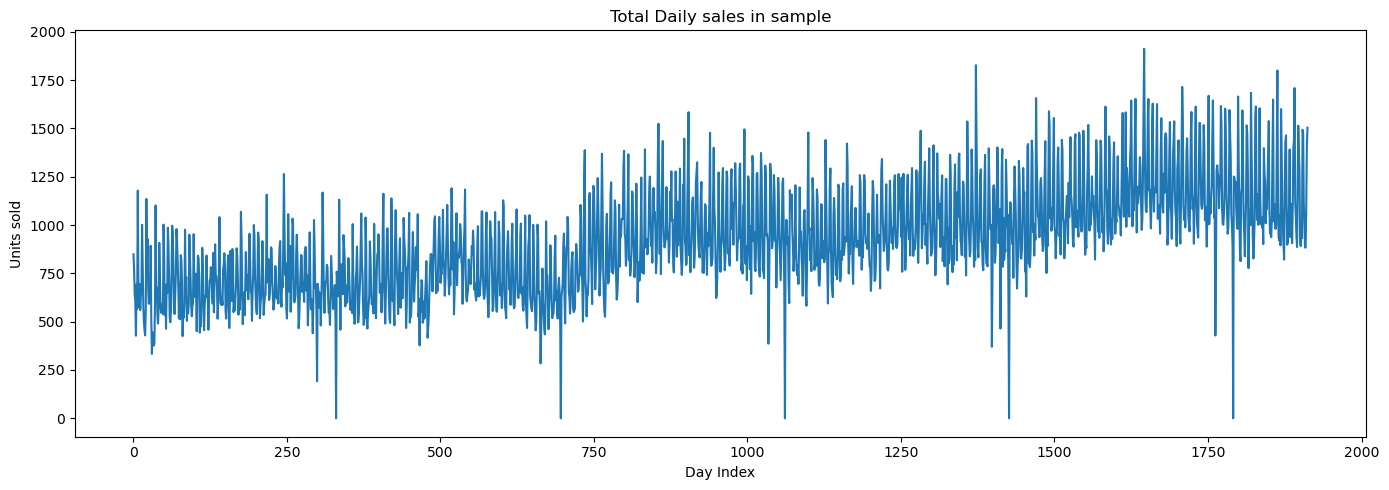

In [24]:
plt.figure(figsize=(14,5))
plt.plot(daily_total.values)
plt.title("Total Daily sales in sample")
plt.xlabel("Day Index")
plt.ylabel("Units sold")
plt.tight_layout()
plt.show()

In [36]:
#Check zero-demand behavior 
daily_values = sales_sample[numeric_sales_columns]
zero_percentage = (
    (daily_values == 0).sum().sum()
    / daily_values.size
) * 100
print(f"Zero-sales percentage: {zero_percentage:.2f}%")

Zero-sales percentage: 67.21%
